<a href="https://colab.research.google.com/github/AlekAbrams/ann_traffic_final_project/blob/main/ANN_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("Traffic_Volume_Counts_20251111.csv")

# Remove commas and convert all hourly traffic columns to numeric
hourly_cols = [col for col in df.columns if ":" in col]

# Replace weird values with NaN
df[hourly_cols] = df[hourly_cols].replace(
    ["", " ", "-", "–", ".", "N/A", "NaN", None], np.nan
)

# Remove commas + convert to numeric
for col in hourly_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", ""), errors="coerce")

# Drop rows where all hourly values are NaN
df = df.dropna(subset=hourly_cols, how="all")

for col in hourly_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace("", np.nan)                 # empty → NaN
        .astype(float)
    )

# Fix date format (NYC is usually month/day/year)
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y", errors="coerce")

# Identify hourly columns
hourly_cols = [col for col in df.columns if ":" in col]
print("Hour columns found:", len(hourly_cols))

# Melt hourly cols
df_long = df.melt(
    id_vars=["ID", "SegmentID", "Roadway Name", "From", "To", "Direction", "Date"],
    value_vars=hourly_cols,
    var_name="Hour",
    value_name="Traffic_Count"
)

# hour parser
def extract_start_time(hour_string):
    try:
        start = hour_string.split("-")[0].strip()      # "12:00"
        end = hour_string.split("-")[1].strip()        # "1:00 AM"

        # If start doesn't include AM/PM, borrow from the ending
        if "AM" not in start and "PM" not in start:
            suffix = end[-2:]                         # "AM" or "PM"
            start = f"{start} {suffix}"               # "12:00 AM"

        # Convert to datetime time
        return pd.to_datetime(start, format="%I:%M %p")
    except:
        return pd.NaT


df_long["Start_Time"] = df_long["Hour"].apply(extract_start_time)

# Drop invalid rows
df_long = df_long.dropna(subset=["Date", "Start_Time"])

# Extract hours and minutes from Start_Time (help from chat)
df_long["Start_Hour"] = df_long["Start_Time"].dt.hour
df_long["Start_Minute"] = df_long["Start_Time"].dt.minute

# Build Datetime safely
df_long["Datetime"] = (
    df_long["Date"].dt.normalize()
    + pd.to_timedelta(df_long["Start_Hour"], unit="h")
    + pd.to_timedelta(df_long["Start_Minute"], unit="m")
)

df_long = df_long.sort_values(by=["SegmentID", "Datetime"]).reset_index(drop=True)


Hour columns found: 24


In [5]:
print("Unique segments:", df_long["SegmentID"].nunique())
print("Unique dates:", df_long["Date"].nunique())

print("\nTop 10 largest segments (by hourly rows):")
print(df_long.groupby("SegmentID").size().sort_values(ascending=False).head(10))

print("\nDatetime range:")
print(df_long["Datetime"].min(), "→", df_long["Datetime"].max())
df_long.head()

Unique segments: 1956
Unique dates: 608

Top 10 largest segments (by hourly rows):
SegmentID
107111    1680
91529     1680
76510     1680
77424     1680
77328     1680
72026     1680
184562    1632
19874     1584
78877     1584
63023     1584
dtype: int64

Datetime range:
2012-01-08 00:00:00 → 2021-05-09 23:00:00


,ID,SegmentID,Roadway Name,From,To,Direction,Date,Hour,Traffic_Count,Start_Time,Start_Hour,Start_Minute,Datetime
0,200,202,Main Street,Hoover Avenue,82 Drive,SB,2014-10-11,12:00-1:00 AM,305.0,1900-01-01 00:00:00,0,0,2014-10-11 00:00:00
1,200,202,Main Street,Hoover Avenue,82 Drive,SB,2014-10-11,1:00-2:00AM,222.0,1900-01-01 01:00:00,1,0,2014-10-11 01:00:00
2,200,202,Main Street,Hoover Avenue,82 Drive,SB,2014-10-11,2:00-3:00AM,137.0,1900-01-01 02:00:00,2,0,2014-10-11 02:00:00
3,200,202,Main Street,Hoover Avenue,82 Drive,SB,2014-10-11,3:00-4:00AM,138.0,1900-01-01 03:00:00,3,0,2014-10-11 03:00:00
4,200,202,Main Street,Hoover Avenue,82 Drive,SB,2014-10-11,4:00-5:00AM,114.0,1900-01-01 04:00:00,4,0,2014-10-11 04:00:00


Train segments: 1564
Test segments: 392
Baseline Model MSE: 440694.62067069154


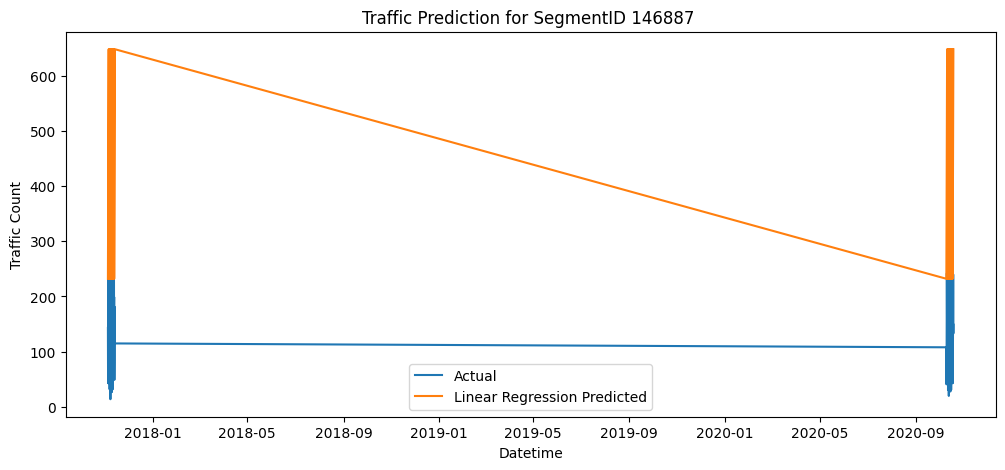

Baseline MSE for 25th hour prediction: 122455.19501253133


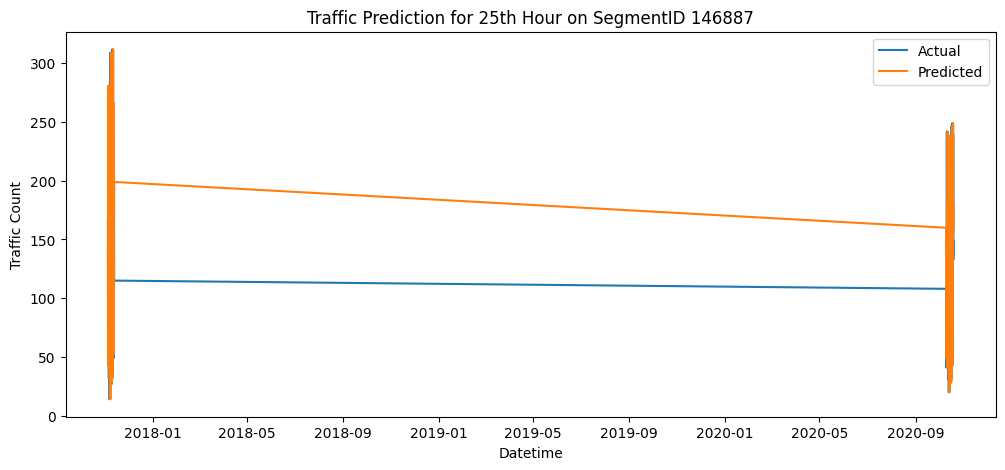

In [6]:
# Baseline model, linear regression

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Starting with preparing to split
X = df_long[["Start_Hour"]]
y = df_long["Traffic_Count"]

# Still having weird issue with NAs that is appearing with this code
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]
df_clean = df_long[mask]

# Splitting by SegmentID (street) to keep streets either in test or train, not both
segments = df_long["SegmentID"].unique()

train_segments, test_segments = train_test_split(segments, test_size=0.2, random_state=42)

print("Train segments:", len(train_segments))
print("Test segments:", len(test_segments))


# Extra precaution to avoid error
train_mask = df_clean["SegmentID"].isin(train_segments)
test_mask  = df_clean["SegmentID"].isin(test_segments)

X_train = X[train_mask]
y_train = y[train_mask]
X_test  = X[test_mask]
y_test  = y[test_mask]

# Now, data is split, so moving to the actual baseline model
lr = LinearRegression()
lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)
baseline_mse = mean_squared_error(y_test, lr_pred)


print("Baseline Model MSE:", baseline_mse)

import matplotlib.pyplot as plt

# Plotting actual vs predicted
# Just making a copy to be safe bc I am adjusting the dataset slightly for best modeling
df_test = df_clean[test_mask].copy()
df_test["Predicted"] = lr_pred
df_test["Actual"] = y_test.values
# Big dataset, so just plotting a segment
first_seg = test_segments[0]
seg_df = df_test[df_test["SegmentID"] == first_seg]

# Creating a model representation
plt.figure(figsize=(12,5))
plt.plot(seg_df["Datetime"], seg_df["Actual"], label="Actual")
plt.plot(seg_df["Datetime"], seg_df["Predicted"], label="Linear Regression Predicted")
plt.xlabel("Datetime")
plt.ylabel("Traffic Count")
plt.title(f"Traffic Prediction for SegmentID {first_seg} ")
plt.legend()
plt.show()


# Additional (more useful) baseline for predicting the 25th hour

#Again, new version to be safe
df_clean = df_clean.sort_values(["SegmentID", "Datetime"]).copy()

#Since I want to predict the 25th hour, I am designating this here to account for the previous 24 hours
df_clean["Previous 24 Hours"] = df_clean.groupby("SegmentID")["Traffic_Count"].shift(24)
# Dropping nas just in case
df_hr = df_clean.dropna(subset=["Previous 24 Hours"])

# Since I am doing a new subset, must go through train/test
hr_train = df_hr[train_mask.loc[df_hr.index]]
hr_test  = df_hr[test_mask.loc[df_hr.index]]
y_test_hr = hr_test["Traffic_Count"]
hr_pred = hr_test["Previous 24 Hours"]
hr_mse = mean_squared_error(y_test_hr, hr_pred)

print("Baseline MSE for 25th hour prediction:", hr_mse)
seg_hr = hr_test[hr_test["SegmentID"] == first_seg]

plt.figure(figsize=(12,5))
plt.plot(seg_hr["Datetime"], seg_hr["Traffic_Count"], label="Actual")
plt.plot(seg_hr["Datetime"], seg_hr["Previous 24 Hours"], label="Predicted")
plt.xlabel("Datetime")
plt.ylabel("Traffic Count")
plt.title(f"Traffic Prediction for 25th Hour on SegmentID {first_seg}")
plt.legend()
plt.show()



In [7]:
# start training LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

n_hours = 24
segments = df_long["SegmentID"].unique()
print("Total segments:", len(segments))
np.random.seed(42)
np.random.shuffle(segments)
cut = int(len(segments) * 0.8)
train_segments = segments[:cut]
test_segments  = segments[cut:]

print("Train segments:", len(train_segments))
print("Test segments:", len(test_segments))

X_train, y_train = [], []
X_test, y_test = [], []

for seg_id, group in df_long.groupby("SegmentID"):
    group = group.sort_values("Datetime")
    data = group["Traffic_Count"].values.reshape(-1, 1)

    # Skip segments with missing values
    if np.isnan(data).any():
        continue

    # TO DO: can we figure out what the segments actually are? my model is performing
    # a little TOO well to the point where it's suspicious. MSE : 0.007644017032229663
# RMSE: 0.08743006938250514
# MAE : 0.06173588629323003
# R²  : 0.8744052142291455


    # Skip flat segments
    if np.min(data) == np.max(data):
        continue

    # Scale per segment
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data).flatten()

    if len(data_scaled) <= n_hours:
        continue

    # Create sequences
    for i in range(len(data_scaled) - n_hours):
        X_seq = data_scaled[i:i+n_hours]
        y_val = data_scaled[i+n_hours]

        if seg_id in train_segments:
            X_train.append(X_seq)
            y_train.append(y_val)
        else:
            X_test.append(X_seq)
            y_test.append(y_val)

X_train = np.array(X_train)
y_train = np.array(y_train)
X_test  = np.array(X_test)
y_test  = np.array(y_test)

print("Train X:", X_train.shape)
print("Test X :", X_test.shape)

X_train = X_train.reshape((X_train.shape[0], n_hours, 1))
X_test  = X_test.reshape((X_test.shape[0], n_hours, 1))

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

Total segments: 1956
Train segments: 1564
Test segments: 392
Train X: (713232, 24)
Test X : (181920, 24)
X_train: (713232, 24, 1)
X_test : (181920, 24, 1)


In [ ]:
model = Sequential([
    LSTM(64, activation="tanh", return_sequences=False, input_shape=(n_hours, 1)),
    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.summary()
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)
# first predict the value, make sure streets are either in train/test data, but not in both
y_pred = model.predict(X_test)
# test_loss = model.evaluate(X_test, y_test)
# print("Test MSE:", test_loss)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
17831/17831 ━━━━━━━━━━━━━━━━━━━━ 271s 15ms/step - loss: 0.0194 - val_loss: 0.0117
Epoch 2/10
17831/17831 ━━━━━━━━━━━━━━━━━━━━ 348s 17ms/step - loss: 0.0107 - val_loss: 0.0100
Epoch 3/10
17831/17831 ━━━━━━━━━━━━━━━━━━━━ 303s 15ms/step - loss: 0.0093 - val_loss: 0.0092
Epoch 4/10
17831/17831 ━━━━━━━━━━━━━━━━━━━━ 319s 15ms/step - loss: 0.0088 - val_loss: 0.0090
Epoch 5/10
17831/17831 ━━━━━━━━━━━━━━━━━━━━ 258s 14ms/step - loss: 0.0084 - val_loss: 0.0096
Epoch 6/10
17831/17831 ━━━━━━━━━━━━━━━━━━━━ 259s 15ms/step - loss: 0.0081 - val_loss: 0.0084
Epoch 7/10
17831/17831 ━━━━━━━━━━━━━━━━━━━━ 267s 15ms/step - loss: 0.0079 - val_loss: 0.0082
Epoch 8/10
17831/17831 ━━━━━━━━━━━━━━━━━━━━ 275s 15ms/step - loss: 0.0077 - val_loss: 0.0081
Epoch 9/10
17831/17831 ━━━━━━━━━━━━━━━━━━━━ 271s 15ms/step - loss: 0.0076 - val_loss: 0.0081
Epoch 10/10
17831/17831 ━━━━━━━━━━━━━━━━━━━━ 255s 14ms/step - loss: 0.0075 - val_loss: 0.0085
5685/5685 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)
# check st dev of error

MSE : 0.007644017032229663
RMSE: 0.08743006938250514
MAE : 0.06173588629323003
R²  : 0.8744052142291455


In [ ]:
def predict_next_hour(segment_id):
    """
    Predicts the next hour of traffic for any segment in the dataset.
    Automatically scales using the last 24 hours of that segment.
    (help from chat)
    """
    group = df_long[df_long["SegmentID"] == segment_id].sort_values("Datetime")

    if len(group) < n_hours:
        raise ValueError("Not enough hourly data for this segment")

    last_24 = group["Traffic_Count"].values[-n_hours:].reshape(-1,1)

    scaler = MinMaxScaler()
    scaled_24 = scaler.fit_transform(last_24)

    X_input = scaled_24.reshape((1, n_hours, 1))

    scaled_pred = model.predict(X_input)[0][0]
    next_hour_value = scaler.inverse_transform([[scaled_pred]])[0][0]

    print(f"Segment {segment_id} next hour prediction:", next_hour_value)
    return next_hour_value

In [ ]:
predict_next_hour(15047)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Segment 15047 next hour prediction: 93.85430900752546


np.float64(93.85430900752546)

In [11]:
# loss curves
from matplotlib import pyplot as plt
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("LSTM Training Curve")
plt.show()

NameError: name 'history' is not defined

In [ ]:
# error distribution
errors = y_pred.flatten() - y_test.flatten()

plt.figure(figsize=(8,4))
plt.hist(errors, bins=40)
plt.title("Error Distribution (Residuals)")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

NameError: name 'y_pred' is not defined

In [8]:
# actual vs predicted
n = 500
y_true_plot = y_test[:n]
y_pred_plot = y_pred[:n].flatten()

plt.figure(figsize=(12,4))
plt.plot(y_true_plot, label="Actual")
plt.plot(y_pred_plot, label="Predicted")
plt.title("Actual vs Predicted Traffic (Test Set)")
plt.xlabel("Sample Index")
plt.ylabel("Scaled Traffic Count")
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'y_pred' is not defined

In [9]:
def predict_next_24_hours(segment_id):
    """
    Predicts the next 24 hours of traffic for any segment using recursion
    Wrote this myself, however was closely modeled after predict_next_hour
    which was written by chat.
    """

    group = df_long[df_long["SegmentID"] == segment_id].sort_values("Datetime")

    if len(group) < n_hours:
        raise ValueError("Not enough data for this segment.")

    # Last 24 hours of actual data
    last_24 = group["Traffic_Count"].values[-n_hours:].reshape(-1,1)

    scaler = MinMaxScaler()
    scaled_hist = scaler.fit_transform(last_24)

    window = scaled_hist.flatten().tolist()
    preds_scaled = []

    for _ in range(24):
        X_input = np.array(window[-n_hours:]).reshape((1, n_hours, 1))
        next_scaled = model.predict(X_input)[0][0]

        preds_scaled.append(next_scaled)
        window.append(next_scaled)

    preds = scaler.inverse_transform(np.array(preds_scaled).reshape(-1,1)).flatten()

    # Create future timestamps (1-hour increments)
    last_time = group["Datetime"].iloc[-1]
    future_times = [last_time + pd.Timedelta(hours=i+1) for i in range(24)]

    future_df = pd.DataFrame({
        "Datetime": future_times,
        "Predicted_Traffic": preds
    })

    return future_df

In [10]:
predict_next_24_hours(15047)

NameError: name 'model' is not defined